In [1]:
## -- Device-Agnostic for GPU --
import torch
print(f"ℹ️ Running on Cuda: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    from cuml.preprocessing import TargetEncoder as cuTE
else:
    pass

ℹ️ Running on Cuda: False


In [2]:
## -- IMPORT LIBRARIES --
import sys, os, gc

## -- DATA MANIPUALATION --
import numpy as np, pandas as pd, random

## -- VISUALISATION --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns
import shap

## -- FUNCTIONAL TOOLS --
from time import time, sleep
from tqdm.notebook import tqdm
from itertools import combinations, product

## -- MACHINE LEARNING --
import xgboost as xgb

import sklearn
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.metrics import (
                roc_auc_score,
                RocCurveDisplay,
                ConfusionMatrixDisplay,
                classification_report
)

import warnings

In [3]:
print(f"sklearn version: {sklearn.__version__}")
print(f"xgboost version: {xgb.__version__}")

sklearn version: 1.2.2
xgboost version: 2.0.3


In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
# plt.style.use("ggplot")
sns.set_style("darkgrid")
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

COLOR = '\033[32m'
RESET = '\033[0m'

In [5]:
## -- Load Data --
PATH = '/kaggle/input/playground-series-s5e12/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv") #.drop('id', axis=1)
test = pd.read_csv(PATH+"test.csv") #.drop('id', axis=1)

TARGET = train.columns[-1]
NUMS = test.select_dtypes(include='number').columns.tolist()
CATS = test.select_dtypes(exclude='number').columns.tolist()
BASE = NUMS + CATS

ORIG_PATH = '/kaggle/input/diabetes-health-indicators-dataset/'
orig = pd.read_csv(ORIG_PATH+'diabetes_dataset.csv')

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (700000, 26)
Test shape: (300000, 25)
Original shape: (100000, 31)

Total Numerical: 19
Total Categorical: 6
Total base features: 25


In [6]:
display(orig.head(3))
# orig = orig[BASE+[TARGET]]

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,Type 2,1


In [7]:
# ### Load Data ###
# submit = pd.read_csv("sample_submission.csv")
# train = pd.read_csv("train.csv",index_col='id') #.drop('id', axis=1)
# test = pd.read_csv("test.csv", index_col='id') #.drop('id', axis=1)

# TARGET = "loan_paid_back"
# NUMS = test.select_dtypes(include='number').columns.tolist()
# CATS = test.select_dtypes(exclude='number').columns.tolist()
# BASE = NUMS + CATS

# orig = pd.read_csv("loan_dataset_20000.csv")[BASE+[TARGET]]

# for (name, df) in dict(Train=train, Test=test, Original=orig).items():
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Numerical: {len(NUMS)}")
# print(f"Total Categorical: {len(CATS)}")
# print(f"Total base features: {len(BASE)}")

In [8]:
train.nunique(dropna=False).sort_values(ascending=False)

id                                    700000
physical_activity_minutes_per_week       565
bmi                                      231
triglycerides                            228
cholesterol_total                        154
ldl_cholesterol                          151
screen_time_hours_per_day                151
diet_score                                99
age                                       71
systolic_bp                               71
hdl_cholesterol                           69
sleep_hours_per_day                       69
heart_rate                                60
diastolic_bp                              54
waist_to_hip_ratio                        36
alcohol_consumption_per_week               9
ethnicity                                  5
income_level                               5
education_level                            4
employment_status                          4
gender                                     3
smoking_status                             3
family_his

# FEATURE ENGINEERING

In [9]:
## -- Factorize using combined data --
for c in CATS:
    combined = pd.concat([train[c], test[c], orig[c]], ignore_index=True)
    combined = combined.factorize()[0]
    train[c] = combined[:len(train)].astype("int8")
    test[c]  = combined[len(train):len(train)+len(test)].astype("int8")
    orig[c]  = combined[-len(orig):].astype("int8")

print('Label encoding complete!!')

Label encoding complete!!


In [10]:
# combine = pd.concat([train, test, orig], ignore_index=True)

# ## -- Ratios/Combinations (Categorical/Ordinal) --
# eps = 1e-6
# combine['Cholesterol_Ratio'] = combine['cholesterol_total'] / (combine['hdl_cholesterol'] + eps)
# combine['Metabolic_Health_Index'] = combine['waist_to_hip_ratio'] * combine['bmi']
# combine['Activity_Per_Screen_Ratio'] = combine['physical_activity_minutes_per_week'] / (combine['screen_time_hours_per_day'] * 60 + eps)
# combine['Diet_Quality_Index'] = combine['diet_score'] - combine['alcohol_consumption_per_week']

# ## -- BP Classification (Categorical/Ordinal) --
# def classify_bp(row):
#     systolic = row['systolic_bp']
#     diastolic = row['diastolic_bp']
#     if systolic < 120 and diastolic < 80:
#         return 'Normal'
#     elif (systolic >= 120 and systolic < 130) and diastolic < 80:
#         return 'Elevated'
#     elif (systolic >= 130 and systolic < 140) or (diastolic >= 80 and diastolic < 90):
#         return 'Stage_1_HTN'
#     elif systolic >= 140 or diastolic >= 90:
#         return 'Stage_2_HTN'
#     else:
#         return 'Crisis' # Should be rare

# combine['BP_Class'] = combine.apply(classify_bp, axis=1)

# print('Combined engineering complete!!')
# CATS.extend(['BP_Class'])

# ## -- Factorize Objects --
# for c in combine.columns:
#     if combine[c].dtype == 'object':
#         combine[c], _ = combine[c].factorize()

# display(combine.head())

# train = combine[:len(train)]
# test  = combine[len(train):len(train)+len(test)]
# orig  = combine[-len(orig):]

In [11]:
# ## -- os.walk: Deep search with subfolders --
# folder_path = '/kaggle/input/ps5e12-extra-orig-features'

# train_orig_extra = pd.DataFrame()
# test_orig_extra = pd.DataFrame()

# print("Loading .npy: ", end="")
# for (root, dirs, files) in os.walk(folder_path):
#     for i, file in enumerate(sorted(files), 1):
#         if i%5 == 0: print(f"{i}%.. ", end="")
#         if file.endswith(".npy") and "train" in file:
#             train_path = np.load(os.path.join(root, file))
#             train_orig_extra = pd.concat([train_orig_extra, pd.Series(train_path, name=file[6:-4])], axis=1)
#         elif file.endswith(".npy") and "test" in file:
#             test_path = np.load(os.path.join(root, file))
#             test_orig_extra = pd.concat([test_orig_extra, pd.Series(test_path, name=file[5:-4])], axis=1)
# print()
# print("Loading .parquet files: ", end="")
# for (root, dirs, files) in os.walk(folder_path):
#     for i, file in enumerate(sorted(files), 1):
#         if i%5 == 0: print(f"{i}%.. ", end="")
#         if file.endswith(".parquet") and "train" in file:
#             train_path = os.path.join(root, file)
#             train_orig_extra = pd.concat([train_orig_extra, pd.read_parquet(train_path)], axis=1)
#         elif file.endswith(".parquet") and "test" in file:
#             test_path = os.path.join(root, file)
#             test_orig_extra = pd.concat([test_orig_extra, pd.read_parquet(test_path)], axis=1)
# print()

# print(f"Total train models: {len(train_orig_extra.columns)} || Shape: {train_orig_extra.shape}")
# print(f"Total test models : {len(test_orig_extra.columns)} || Shape: {test_orig_extra.shape}")

# train = pd.concat([train, train_orig_extra], axis=1)
# test = pd.concat([test, test_orig_extra], axis=1)
# print(f"\n✅ All external features merged!")

# train.head()

In [12]:
## -- View extra columns --
sorted(os.listdir('/kaggle/input/ps5e12-extra-orig-features'))

['test_AG_on_diabetes_stage.parquet',
 'test_AG_on_glucose_fasting.npy',
 'test_AG_on_hba1c.npy',
 'test_AG_on_insulin_level.npy',
 'test_on_diabetes_risk_score.npy',
 'train_AG_on_diabetes_stage.parquet',
 'train_AG_on_glucose_fasting.npy',
 'train_AG_on_hba1c.npy',
 'train_AG_on_insulin_level.npy',
 'train_on_diabetes_risk_score.npy']

In [13]:
# ## -- os.listdir: Shallow search in a single folder --
# folder_path = '/kaggle/input/ps5e12-extra-orig-features/'

# train_extra = pd.DataFrame()
# test_extra = pd.DataFrame()

# print("Loading .npy: ", end="")
# for i, file in enumerate(sorted(os.listdir(folder_path))):
#     file_path = folder_path + file
#     if i%5 == 0: print(f"{i}%.. ", end="")
#     if file.endswith(".npy") and "train" in file:
#         train_extra = pd.concat([train_extra, pd.Series(np.load(file_path), name=file[6:-4])], axis=1)
#     elif file.endswith(".npy") and "test" in file:
#         test_extra = pd.concat([test_extra, pd.Series(np.load(file_path), name=file[5:-4])], axis=1)
# print()
# print("Loading .parquet files: ", end="")
# for i, file in enumerate(sorted(os.listdir(folder_path))):
#     file_path = folder_path + file
#     if i%10 == 0: print(f"{i}%.. ", end="")
#     if file.endswith(".parquet") and "train" in file:
#         train_extra = pd.concat([train_extra, pd.read_parquet(file_path)], axis=1)
#     elif file.endswith(".parquet") and "test" in file:
#         test_extra = pd.concat([test_extra, pd.read_parquet(file_path)], axis=1)
# print()

# print(f"Total train models: {len(train_extra.columns)} || Shape: {train_extra.shape}")
# print(f"Total test models : {len(test_extra.columns)} || Shape: {test_extra.shape}")

# train = pd.concat([train, train_extra], axis=1)
# test = pd.concat([test, test_extra], axis=1)
# print(f"\n✅ All external features merged!")

# display(train.head())
# display(test.head())

In [14]:
# drop_cols = [
#     'AG_on_hba1c',
#     'AG_on_glucose_fasting',
#     'diabetes_stage',
#     'on_diabetes_risk_score',
#     # 'AG_on_insulin_level',
# ]
# NEW_COLS = ['AG_on_insulin_level']

# train.drop(drop_cols, axis=1, inplace=True)
# test.drop(drop_cols, axis=1, inplace=True)

# train.head()

In [15]:
# ## -- Bin HBA1c --
# bins = [0, 5.7, 6.4, train['AG_on_hba1c'].max() + 1.0]
# labels = ['Normal', 'Prediabetes', 'Diabetes']

# train['hba1c_Cat'], edges = pd.cut(train['AG_on_hba1c'], bins=bins, duplicates='drop', retbins=True, labels=labels)
# test['hba1c_Cat'] = pd.cut(test['AG_on_hba1c'], bins=edges, include_lowest=True, labels=labels)
# CATS.append('hba1c_Cat')

# combine = pd.concat([train, test, orig], ignore_index=True)

# eps = 1e-6
# combine['HOMA_IR'] = combine['AG_on_glucose_fasting'] * combine['AG_on_insulin_level']
# combine['Cholesterol_Ratio'] = combine['cholesterol_total'] / (combine['hdl_cholesterol'] + eps)
# combine['Activity_Per_Screen_Ratio'] = combine['physical_activity_minutes_per_week'] / (combine['screen_time_hours_per_day'] * 60 + eps)
# combine['Diet_Quality_Index'] = combine['diet_score'] - combine['alcohol_consumption_per_week']

# display(combine.head())

# train = combine[:len(train)]
# test  = combine[len(train):len(train)+len(test)]
# orig  = combine[-len(orig):]

## ROUND - DIGITS - BINS - INTERACTIONS - ORIGINAL TE COLUMNS

Age, for example, varies between around -1 at 20 (25% chance), to +1 at 70 (75% chance). Suppose we have a
* `50 year` old (0),
* with a `BMI` of 35 (0.5),
* taking `no exercise` (+1),
* and a `family history of diabetes` (+1.5).

That works out as 0 + 0.5 + 1 + 1.5 == 3 (~95% chance of diabetes).

In [16]:
# # -- Create base_risk -- 
# for df in [train, test, orig]:
#     risk_factor = (
#         0.1 * (df['age'] >= 50).astype(int) + \
#         0.50 * df['bmi'] + \
#         1.50 * (df['family_history_diabetes'] == 1).astype(int) + \
#         1.00 * (df['physical_activity_minutes_per_week'] >= 200).astype(int)
#     )
#     df['risk_factor'] = risk_factor

# train.sample(10)

In [17]:
# ROUND = []
# for col in tqdm(['age']):#, 'hdl_cholesterol', 'ldl_cholesterol'
#     for r in [-1]:
#         n = f"{col}_r{r}"
#         train[n] = train[col].round(r).astype(int)
#         test[n] = test[col].round(r).astype(int)
#         orig[n] = test[col].round(r).astype(int)
#         ROUND.append(n)

# for col in tqdm(['systolic_bp', 'diastolic_bp', 'heart_rate', 'triglycerides']):
#     for r in [-1]: # -2
#         n = f"{col}_r{r}"
#         train[n] = train[col].round(r).astype(int)
#         test[n] = test[col].round(r).astype(int)
#         orig[n] = test[col].round(r).astype(int)
#         ROUND.append(n)

# for col in tqdm(['diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day']):
#     for r in [0]:
#         n = f"{col}_r{r}"
#         train[n] = train[col].round(r).astype(int)
#         test[n] = test[col].round(r).astype(int)
#         orig[n] = test[col].round(r).astype(int)
#         ROUND.append(n)

# for col in tqdm(['bmi']):
#     for r in [-1, 0]:
#         n = f"{col}_r{r}"
#         train[n] = train[col].round(r).astype(int)
#         test[n] = test[col].round(r).astype(int)
#         orig[n] = test[col].round(r).astype(int)
#         ROUND.append(n)

# for col in tqdm(['physical_activity_minutes_per_week']):
#     for r in [-1, -2]:
#         n = f"{col}_r{r}"
#         train[n] = train[col].round(r).astype(int)
#         test[n] = test[col].round(r).astype(int)
#         orig[n] = test[col].round(r).astype(int)
#         ROUND.append(n)

# for col in tqdm(['waist_to_hip_ratio']):
#     for r in [1]:
#         n = f"{col}_r{r}"
#         train[n] = train[col].round(r).astype(int)
#         test[n] = test[col].round(r).astype(int)
#         orig[n] = test[col].round(r).astype(int)
#         ROUND.append(n)
        
# for col in tqdm(['cholesterol_total']):
#     for r in [-1, -2]:
#         n = f"{col}_r{r}"
#         train[n] = train[col].round(r).astype(int)
#         test[n] = test[col].round(r).astype(int)
#         orig[n] = test[col].round(r).astype(int)
#         ROUND.append(n)

# print(f'{len(ROUND)} ROUND Features created.')
# print(train[ROUND].nunique())

In [18]:
# DIGITS = []

# floats = [
#     'bmi',
#     # 'waist_to_hip_ratio',
#     # 'diet_score',
#     # 'sleep_hours_per_day',
#     # 'screen_time_hours_per_day',
# ]
# for col in tqdm(floats):
#     for d in range(-1, 4):
#         n = f'{col}_d{d}'
#         train[n] = ((train[col] * 10**d) % 10).fillna(-1).astype(int)
#         test[n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype(int)
#         orig[n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype(int)

#         ## -- Drop constant features --
#         if train[n].nunique() < 2:
#             train.drop([n], axis=1, inplace=True)
#             test.drop([n],  axis=1, inplace=True)
#             orig.drop([n],  axis=1, inplace=True)
#         else:
#             DIGITS.append(n)

# print(f'{len(DIGITS)} Features DIGITS extracted.')
# print(train[DIGITS].nunique())

## USE EXTERNAL ORIGINAL FEATURES

In [19]:
## -- Merging original features as columns --
ORIG = []

for col in tqdm([c for c in BASE if c != 'id']): # +['bmi_d-1']
    ## -- MEAN
    mean_col = f"OTE_{col}_mean"
    mean_map = orig.groupby(col)[TARGET].mean().reset_index(name=mean_col)

    train = train.merge(mean_map, on=col, how='left')
    test = test.merge(mean_map, on=col, how='left')
    ORIG.append(mean_col)

    ## -- COUNT
    count_col = f"OTE_{col}_count"
    count_map = orig.groupby(col).size().reset_index(name=count_col)

    train = train.merge(count_map, on=col, how='left')
    test = test.merge(count_map, on=col, how='left')
    ORIG.append(count_col)

print(len(ORIG), 'Orig Features Created!!')

  0%|          | 0/24 [00:00<?, ?it/s]

48 Orig Features Created!!


In [20]:
## -- Define categories for OHE --
CAT_COLS = [c for c in BASE if train[c].dtype=='object' or train[c].nunique() <= 0.01*len(train)]
print(f"ℹ️ Features for TE: {len(CAT_COLS)} -> {CAT_COLS}")

ℹ️ Features for TE: 24 -> ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [21]:
from sklearn.base import BaseEstimator, TransformerMixin

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

In [22]:
FEATURES = [c for c in train.columns if c != TARGET]
print('Total Features', len(FEATURES))

Total Features 73


# ML TRAINING

In [23]:
## -- Define Training Parameters -- 
if torch.cuda.is_available():
    print(f"ℹ️ GPU Frame: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ CPU Cores: {os.cpu_count()}")
else:
    print(f"ℹ️ Only CPU: {os.cpu_count()} cores")
## ---------------------------------------------------------
## -- Split main X from last 22k rows --
last_22k_rows = 22_000

X = train[FEATURES].iloc[:train.shape[0] - last_22k_rows, ]
y = train[TARGET].iloc[:train.shape[0] - last_22k_rows, ].astype(int)
X_y = train[~train.index.isin(X.index)]

kf = StratifiedKFold(n_splits=8, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))
fold_scores = []

BINARY_COLS = [c for c in CAT_COLS if train[c].nunique() == 2]
TE_COLS = [c for c in CAT_COLS if c not in BINARY_COLS]

tik = time()
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    print('|', '-'*30)
    print(f"Fold {fold+1}/{kf.n_splits}", end='')

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test[FEATURES].copy()

    ## -- Manual shuffle and re-merge X_y --
    X_y_shuffled = X_y.sample(frac=1, random_state=SEED+fold).reset_index(drop=True).copy()
    X_22K = X_y_shuffled[FEATURES]
    y_22K = X_y_shuffled[TARGET].astype(int)

    ## -- Concatenate 22k on train data
    X_train = pd.concat([X_train, X_22K], ignore_index=True)
    y_train = pd.concat([y_train, y_22K], ignore_index=True)
    
    ## -- TE Opt1. -> Using CUSTOM 
    TE = TargetEncoder(TE_COLS, cv=5, smooth=6.0, aggs=['mean', 'std'], drop_original=False)
    X_train = TE.fit_transform(X_train, y_train)
    X_val   = TE.transform(X_val)
    X_test  = TE.transform(X_test)

    # TE2 = TargetEncoder(NEW_COLS, cv=5, smooth=5.0, aggs=['mean'], drop_original=True)
    # X_train = TE2.fit_transform(X_train, y_train)
    # X_val   = TE2.transform(X_val)
    # X_test  = TE2.transform(X_test)

    # ## -- TE Opt2. -- Using RAPIDS 
    # for c in TE_COLS:
    #     TE = cuTE(n_folds=5, smooth=2.0, stat='mean', split_method='random', seed=SEED)
    #     n = f"TE_{c}"
    #     X_train[n] = TE.fit_transform(X_train[c], y_train)
    #     X_val[n]   = TE.transform(X_val[c])
    #     X_test[n]  = TE.transform(X_test[c])

    # for c in NEW_COLS:
    #     TE = cuTE(n_folds=5, smooth=2.0, stat='mean', split_method='random', seed=SEED)
    #     X_train[c] = TE.fit_transform(X_train[c], y_train)
    #     X_val[c]   = TE.transform(X_val[c])
    #     X_test[c]  = TE.transform(X_test[c])

    BINS = []
    for c in tqdm(['id'], desc='Binning'):
        for b in [25]:
            n = f"{c}_bin{b}"
            X_train[n], edges = pd.cut(X_train[c], bins=b, duplicates='drop', retbins=True, labels=False)
            X_val[n] = pd.cut(X_val[c], bins=edges, include_lowest=True, labels=False)
            X_test[n] = pd.cut(X_test[c], bins=edges, include_lowest=True, labels=False)
            X_val[n].fillna(-1, inplace=True)
            X_test[n].fillna(-1, inplace=True)
            BINS.append(n)

    for c in CATS: # + DIGITS
        X_train[c] = X_train[c].astype('category')
        X_val[c]   = pd.Categorical(X_val[c], categories=X_train[c].cat.categories)
        X_test[c]  = pd.Categorical(X_test[c], categories=X_train[c].cat.categories)

    print(f"X_train Shape: {X_train.shape}")

    ES_V = 500
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'max_depth': 6,
        'learning_rate': 0.007,
        'n_estimators': 100_000,
        'subsample': 0.95,
        'colsample_bytree': 0.2,
        'reg_alpha': 4.5,
        'random_state': 77,
        'enable_categorical': True,
        'early_stopping_rounds': ES_V,
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'n_jobs': os.cpu_count(),
        'verbose': 0,
    }

    # params = {
    #     'grow_policy': 'lossguide',
    #     'objective': 'binary:logistic',
    #     'eval_metric': 'auc',
    #     'n_estimators': 20_000,
    #     'learning_rate': 0.01,
    #     'max_depth': 0,
    #     'max_leaves': 16,
    #     'subsample': 0.95,
    #     'colsample_bytree': 0.2,
    #     'reg_alpha': 4.0,
    #     # 'reg_lambda': 0.4,
    #     'random_state': SEED,
    #     'enable_categorical': True,
    #     'early_stopping_rounds': ES_V,
    #     'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    #     'n_jobs': os.cpu_count(),
    #     'verbose': 0,
    # }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train,eval_set=[(X_val, y_val)], verbose=ES_V)

    oof = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = oof
    score = roc_auc_score(y_val, oof)
    fold_scores.append(score)
    print(f"{COLOR}\tAUC: {score:.5f}{RESET}")

    test_preds += model.predict_proba(X_test)[:, 1]

test_preds / kf.n_splits

tok = time() 
tiktok = (tok-tik) / 60
print('-'*20)
print(f"\tTraining Time: {tiktok:.2f} mins{RESET}")

ℹ️ Only CPU: 4 cores
| ------------------------------
Fold 1/8

Binning:   0%|          | 0/1 [00:00<?, ?it/s]

X_train Shape: (615250, 116)
[0]	validation_0-auc:0.70849
[500]	validation_0-auc:0.72930
[1000]	validation_0-auc:0.73107
[1500]	validation_0-auc:0.73215
[2000]	validation_0-auc:0.73281
[2500]	validation_0-auc:0.73316
[3000]	validation_0-auc:0.73334
[3500]	validation_0-auc:0.73346
[4000]	validation_0-auc:0.73351
[4500]	validation_0-auc:0.73354
[5000]	validation_0-auc:0.73357
[5500]	validation_0-auc:0.73359
[6000]	validation_0-auc:0.73360
[6500]	validation_0-auc:0.73360
[6653]	validation_0-auc:0.73359
	AUC: 0.73361
| ------------------------------
Fold 2/8

Binning:   0%|          | 0/1 [00:00<?, ?it/s]

X_train Shape: (615250, 116)
[0]	validation_0-auc:0.70537
[500]	validation_0-auc:0.72874
[1000]	validation_0-auc:0.73033
[1500]	validation_0-auc:0.73136
[2000]	validation_0-auc:0.73192
[2500]	validation_0-auc:0.73225
[3000]	validation_0-auc:0.73247
[3500]	validation_0-auc:0.73257
[4000]	validation_0-auc:0.73263
[4500]	validation_0-auc:0.73270
[5000]	validation_0-auc:0.73273
[5500]	validation_0-auc:0.73275
[6000]	validation_0-auc:0.73273
[6281]	validation_0-auc:0.73273
	AUC: 0.73275
| ------------------------------
Fold 3/8

...

X_train Shape: (615250, 116)
[0]	validation_0-auc:0.70862
[500]	validation_0-auc:0.72740
[1000]	validation_0-auc:0.72908
[1500]	validation_0-auc:0.72998
[2000]	validation_0-auc:0.73045
[2500]	validation_0-auc:0.73072
[3000]	validation_0-auc:0.73088
[3500]	validation_0-auc:0.73096
[4000]	validation_0-auc:0.73102
[4500]	validation_0-auc:0.73105
[5000]	validation_0-auc:0.73103
[5146]	validation_0-auc:0.73103
	AUC: 0.73105
| ------------------------------
Fold 7/8

Binning:   0%|          | 0/1 [00:00<?, ?it/s]

X_train Shape: (615250, 116)
[0]	validation_0-auc:0.70892
[500]	validation_0-auc:0.72886
[1000]	validation_0-auc:0.73060
[1500]	validation_0-auc:0.73165
[2000]	validation_0-auc:0.73227
[2500]	validation_0-auc:0.73261
[3000]	validation_0-auc:0.73276
[3500]	validation_0-auc:0.73287
[4000]	validation_0-auc:0.73297
[4500]	validation_0-auc:0.73298
[5000]	validation_0-auc:0.73302
[5500]	validation_0-auc:0.73304
[6000]	validation_0-auc:0.73302
[6102]	validation_0-auc:0.73303
	AUC: 0.73305
| ------------------------------
Fold 8/8

Binning:   0%|          | 0/1 [00:00<?, ?it/s]

X_train Shape: (615250, 116)
[0]	validation_0-auc:0.70777
[500]	validation_0-auc:0.72909
[1000]	validation_0-auc:0.73084
[1500]	validation_0-auc:0.73189
[2000]	validation_0-auc:0.73249
[2500]	validation_0-auc:0.73286
[3000]	validation_0-auc:0.73302
[3500]	validation_0-auc:0.73310
[4000]	validation_0-auc:0.73314
[4500]	validation_0-auc:0.73314
[4744]	validation_0-auc:0.73315
	AUC: 0.73316
--------------------
	Training Time: 93.26 mins


In [24]:
## -- After all folds --
overall_AUC = roc_auc_score(y, oof_preds)

print(f"|{'-'*52}")
print(f"| Overall AUC: {overall_AUC:.5f}")
print(f"| Average AUC: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
print(f"|{'-'*52}")

pred_labels = (oof_preds >= 0.5).astype(int)
print(classification_report(y, pred_labels))

|----------------------------------------------------
| Overall AUC: 0.73282
| Average AUC: 0.73283 ± 0.00172
|----------------------------------------------------
              precision    recall  f1-score   support

           0       0.62      0.44      0.52    255383
           1       0.71      0.84      0.77    422617

    accuracy                           0.69    678000
   macro avg       0.67      0.64      0.64    678000
weighted avg       0.68      0.69      0.67    678000



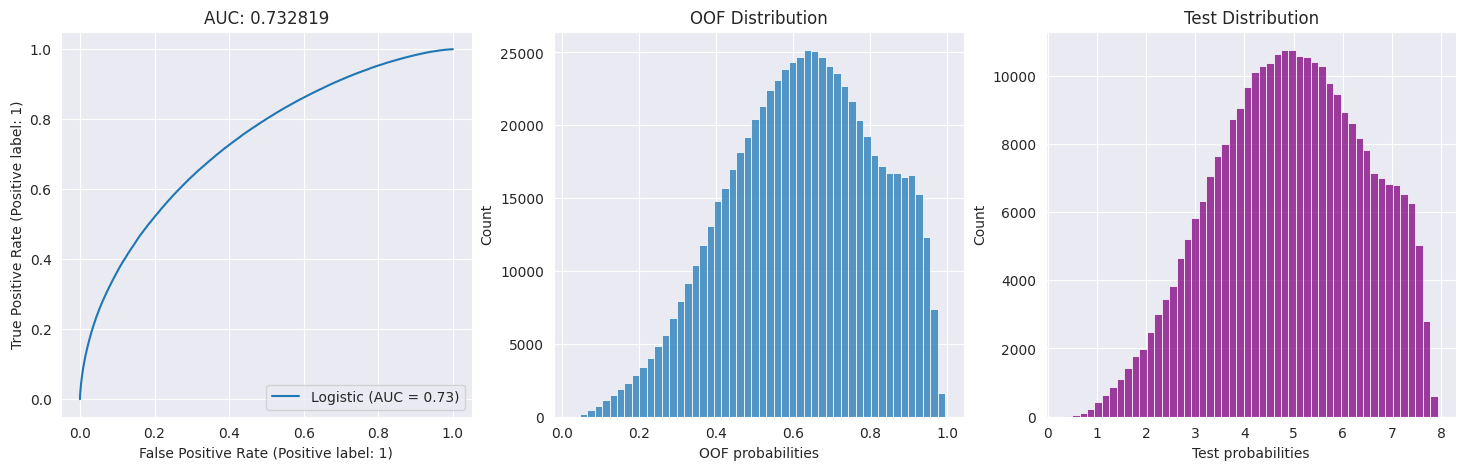

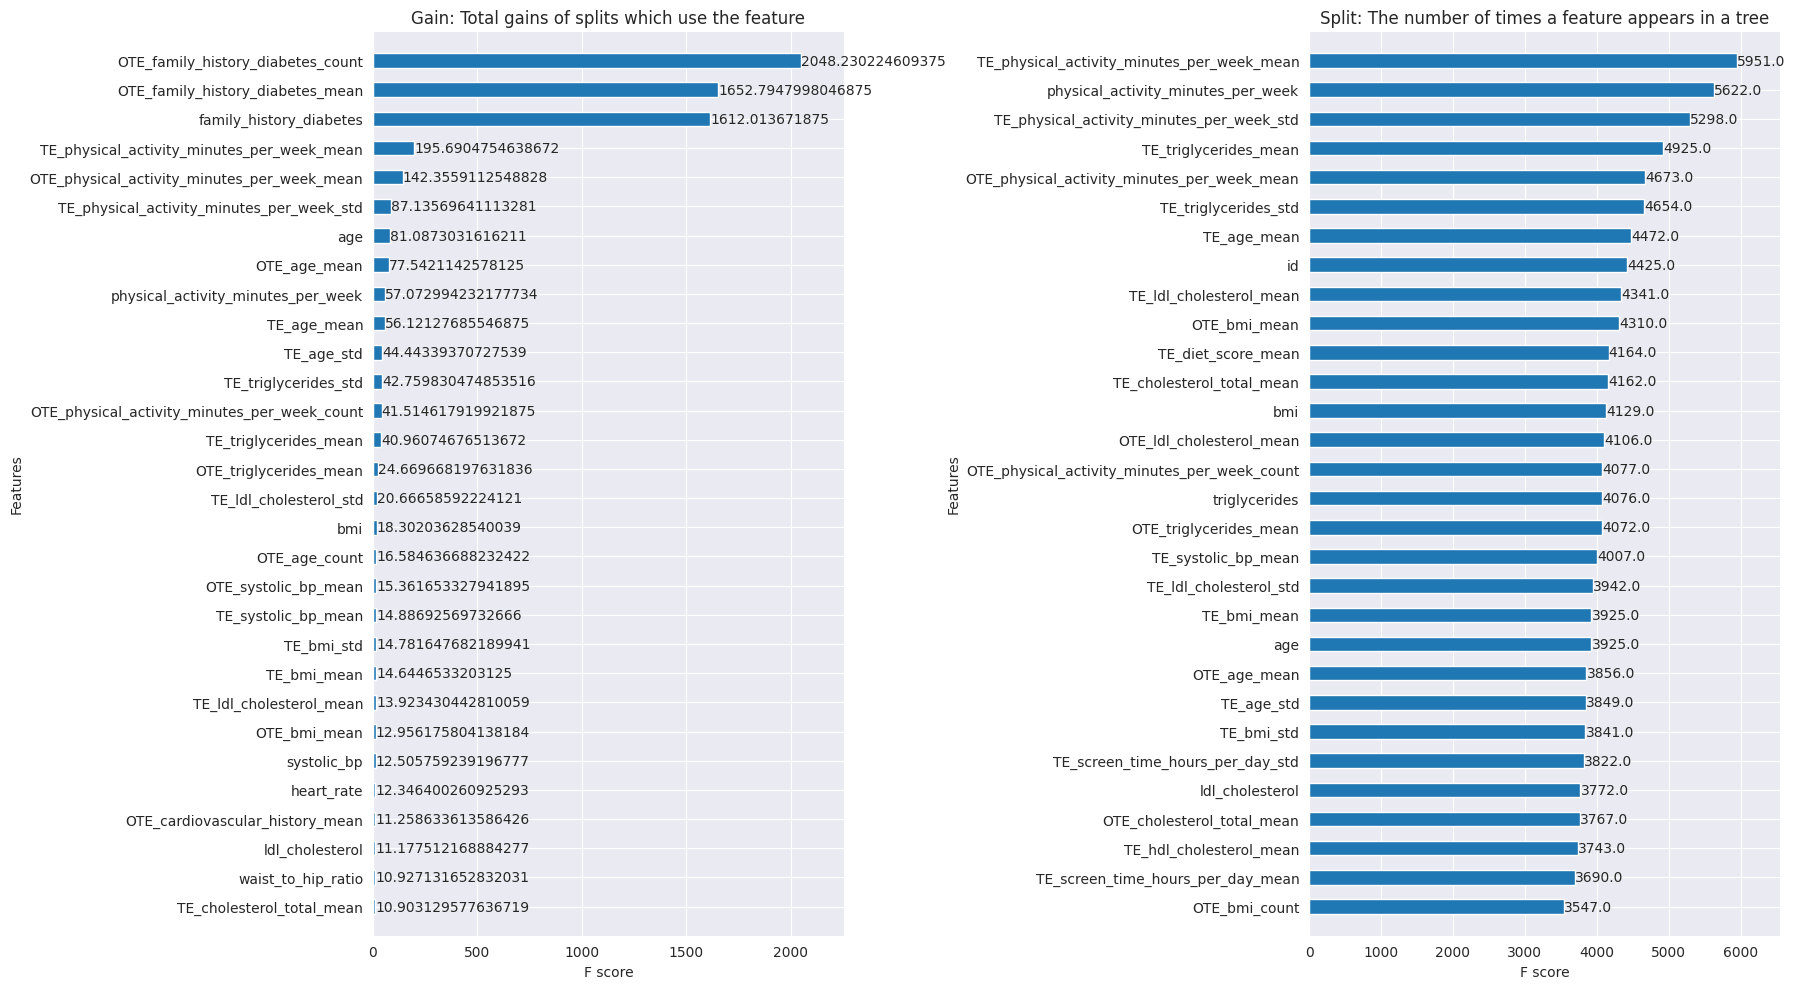

In [25]:
_, axs = plt.subplots(1, 3, figsize=(18, 5))
## -- ROC curve --
RocCurveDisplay.from_predictions(y, oof_preds, name='Logistic', ax=axs[0])
axs[0].set_title(f"AUC: {overall_AUC:.6f}")

## -- Distribution plotS --
sns.histplot(oof_preds, bins=50, ax=axs[1])
axs[1].set_title(f"OOF Distribution")
axs[1].set_xlabel(f"OOF probabilities")

sns.histplot(test_preds, color='purple', bins=50, ax=axs[2])
axs[2].set_title(f"Test Distribution")
axs[2].set_xlabel(f"Test probabilities")

# ## -- Confusion matrix (threshold = 0.5) --
# ConfusionMatrixDisplay.from_predictions(y, pred_labels, cmap='Blues', colorbar=False, ax=axs[3])
# axs[3].set_title(f"Confusion Matrix")
# axs[3].grid(False)

## -- Plot feature importances --
_, axs = plt.subplots(1, 2, figsize=(18, 10))
xgb.plot_importance(model, importance_type='gain', max_num_features=30, height=0.5, ax=axs[0])
axs[0].set_title('Gain: Total gains of splits which use the feature')
xgb.plot_importance(model, importance_type='weight', max_num_features=30, height=0.5, ax=axs[1])
axs[1].set_title('Split: The number of times a feature appears in a tree')

plt.tight_layout()
plt.show()

In [26]:
n = 'XGBid_' + str(round(overall_AUC, 5)).split('.')[1]

np.save(f"oof_{n}.npy", oof_preds)
np.save(f"pred_{n}.npy", test_preds)
print(f"✓ oof & prediction files saved!")

submit[TARGET] = test_preds
submit.to_csv(f"submit_{n}.csv", index=False)
print(f"✓ submit_{n}.csv file saved!")
submit.head()

✓ oof & prediction files saved!
✓ submit_XGBid_73282.csv file saved!


,id,diagnosed_diabetes
0,700000,3.770084
1,700001,5.640057
2,700002,6.297101
3,700003,3.279896
4,700004,7.369590
